In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [7]:
df = pd.read_csv('UpdatedResumeDataSet.csv')

In [8]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:\n{df.head()}")
print(f"\nDataset Info:")
print(df.info())
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

DATASET OVERVIEW

Dataset Shape: (962, 2)

Columns: ['Category', 'Resume']

First few rows:
       Category                                             Resume
0  Data Science  Skills * Programming Languages: Python (pandas...
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...
2  Data Science  Areas of Interest Deep Learning, Control Syste...
3  Data Science  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4  Data Science  Education Details \r\n MCA   YMCAUST,  Faridab...

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB
None

Missing Values:
Category    0
Resume      0
dtype: int64

Duplicate Rows: 796


In [9]:
print("\n" + "="*50)
print("CATEGORY DISTRIBUTION")
print("="*50)
print(df['Category'].value_counts())


CATEGORY DISTRIBUTION
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


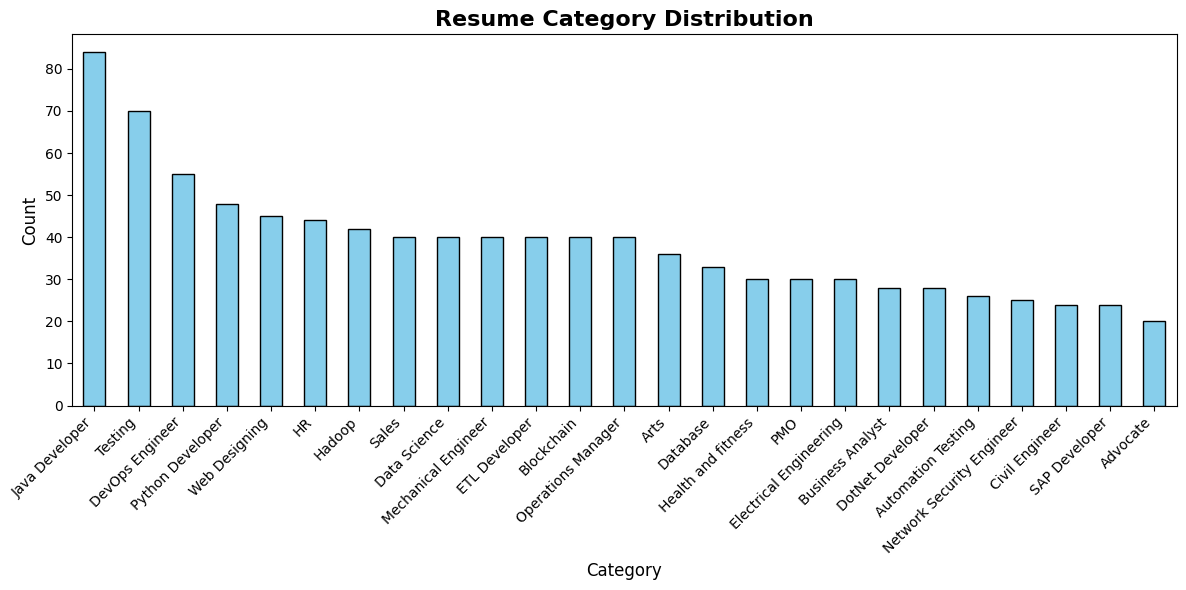

In [10]:
plt.figure(figsize=(12, 6))
df['Category'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Resume Category Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

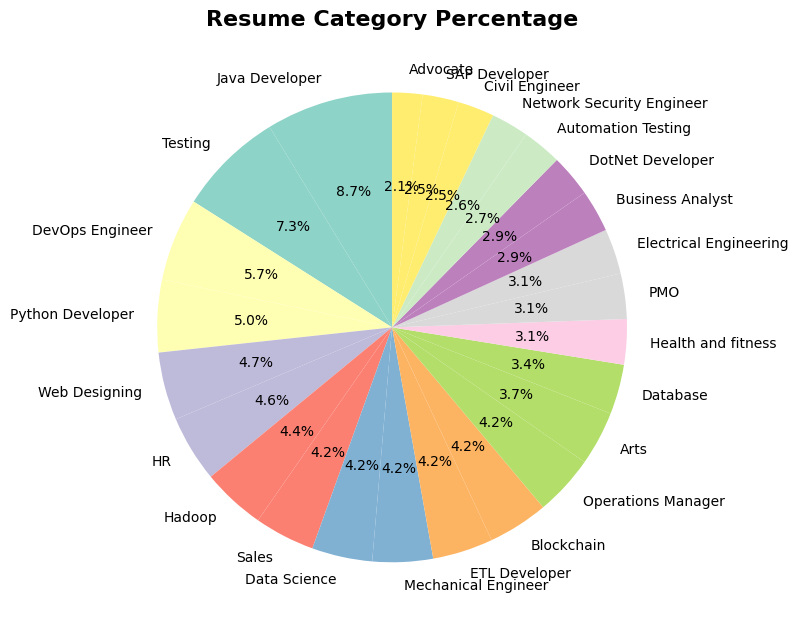

In [12]:
plt.figure(figsize=(8, 8))
df['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Set3')
plt.title('Resume Category Percentage', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('category_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()


In [19]:
def clean_resume(text):
    text = re.sub(r'http\S+\s*', ' ', text)
    text = re.sub(r'RT|cc', ' ', text)
    text = re.sub(r'#\S+', '', text)
    text = re.sub(r'@\S+', '  ', text)
    text = re.sub(r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)
    text = re.sub(r'[^\x00-\x7f]', r' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()


df['cleaned_resume'] = df['Resume'].apply(clean_resume)

df['resume_length'] = df['cleaned_resume'].apply(len)
df['word_count'] = df['cleaned_resume'].apply(lambda x: len(x.split()))

print("\n" + "="*50)
print("RESUME LENGTH STATISTICS")
print("="*50)
print(f"\nCharacter Length Stats:\n{df['resume_length'].describe()}")
print(f"\nWord Count Stats:\n{df['word_count'].describe()}")

<>:6: SyntaxWarning: invalid escape sequence '\]'
<>:6: SyntaxWarning: invalid escape sequence '\]'
C:\Users\prash\AppData\Local\Temp\ipykernel_19516\2292453299.py:6: SyntaxWarning: invalid escape sequence '\]'
  text = re.sub(r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)



RESUME LENGTH STATISTICS

Character Length Stats:
count      962.000000
mean      2913.428274
std       2692.256965
min        118.000000
25%       1125.000000
50%       2133.000000
75%       3639.000000
max      13631.000000
Name: resume_length, dtype: float64

Word Count Stats:
count     962.000000
mean      428.525988
std       394.622759
min        16.000000
25%       160.000000
50%       308.000000
75%       556.500000
max      2064.000000
Name: word_count, dtype: float64


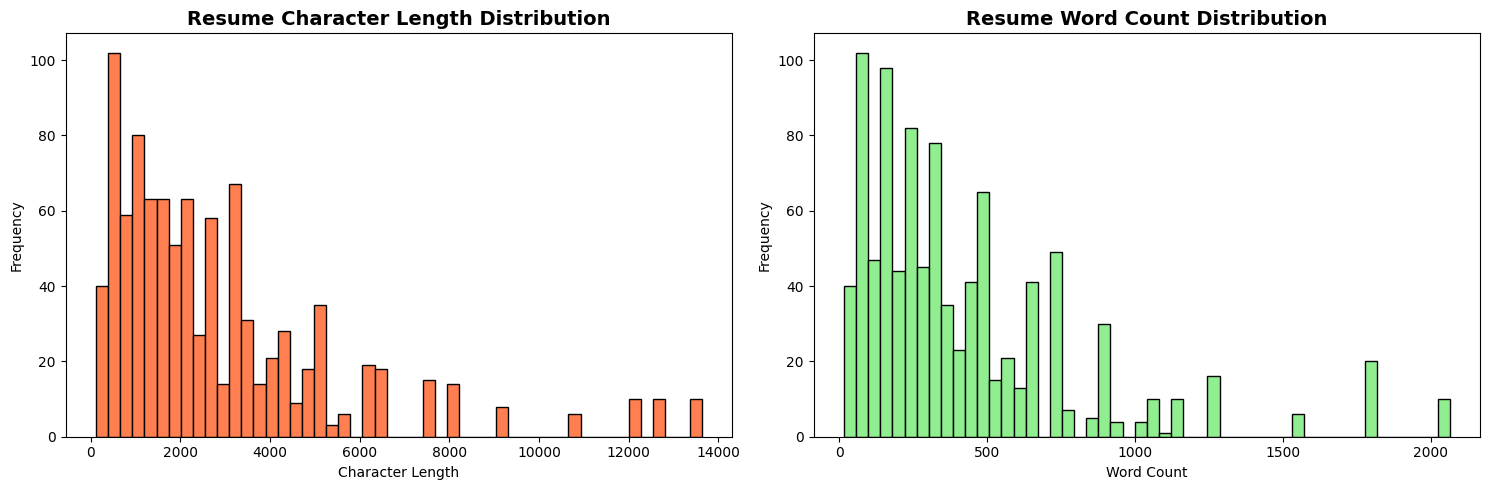

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['resume_length'], bins=50, color='coral', edgecolor='black')
axes[0].set_title('Resume Character Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['word_count'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Resume Word Count Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('resume_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


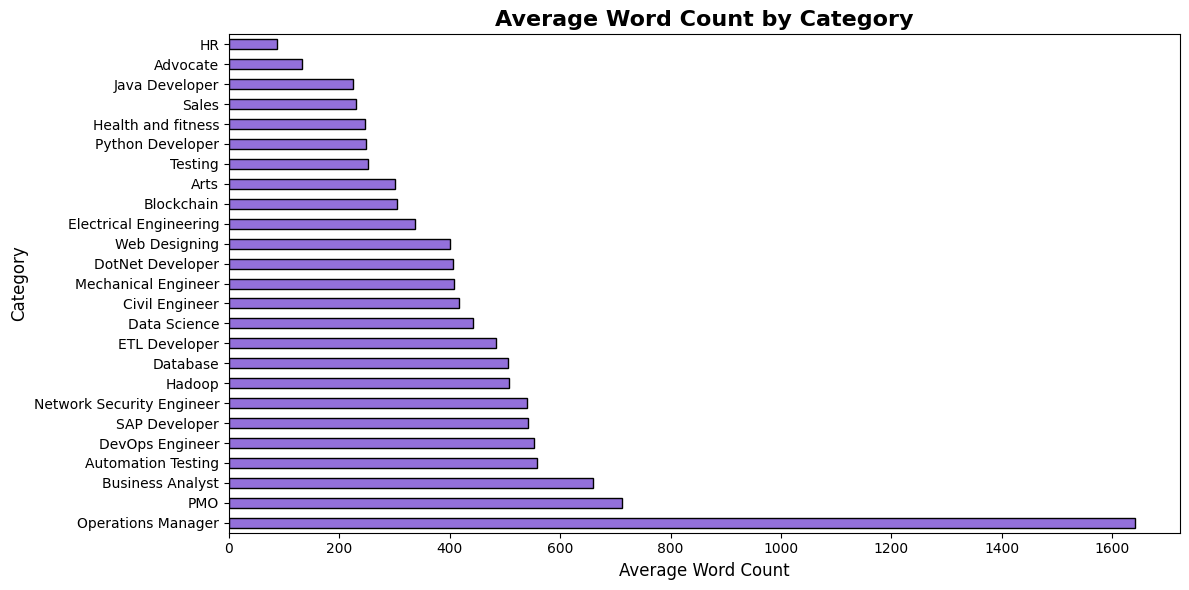

In [21]:
avg_length_by_category = df.groupby('Category')['word_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_length_by_category.plot(kind='barh', color='mediumpurple', edgecolor='black')
plt.title('Average Word Count by Category', fontsize=16, fontweight='bold')
plt.xlabel('Average Word Count', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig('avg_wordcount_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

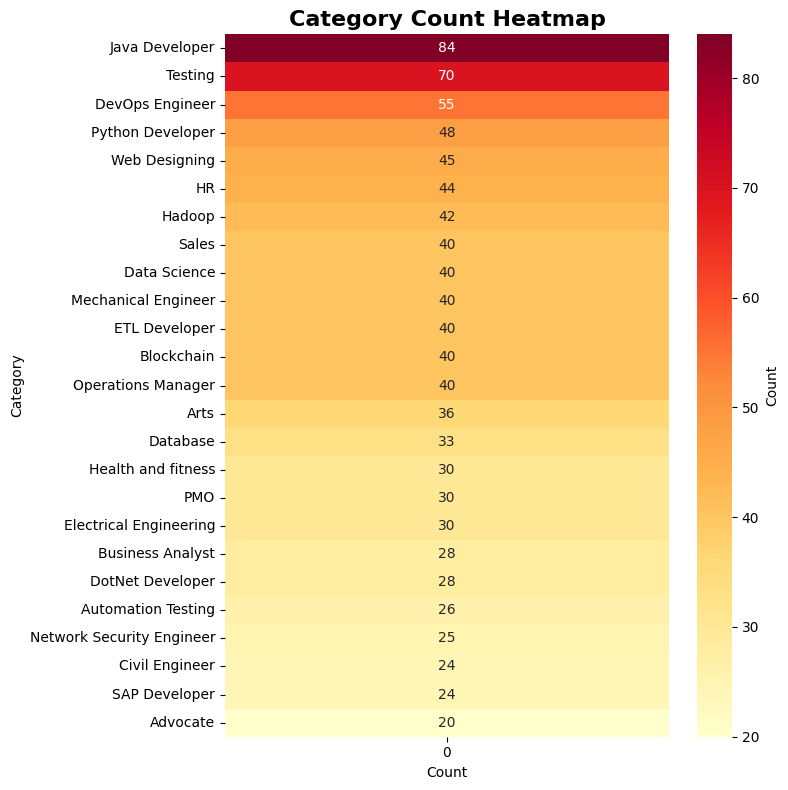

In [22]:
category_counts = df['Category'].value_counts().values.reshape(-1, 1)
plt.figure(figsize=(8, 8))
sns.heatmap(category_counts, annot=True, fmt='d', cmap='YlOrRd', 
            yticklabels=df['Category'].value_counts().index,
            cbar_kws={'label': 'Count'})
plt.title('Category Count Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('category_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_top_words(text_series, n=20):
    all_words = ' '.join(text_series).split()
    filtered_words = [word for word in all_words if word not in ENGLISH_STOP_WORDS and len(word) > 3]
    return Counter(filtered_words).most_common(n)

print("\n" + "="*50)
print("TOP 20 WORDS IN RESUMES")
print("="*50)
top_words = get_top_words(df['cleaned_resume'])
for word, count in top_words:
    print(f"{word}: {count}")


TOP 20 WORDS IN RESUMES
exprience: 3829
company: 3578
project: 3498
months: 3288
description: 3122
details: 3096
data: 2156
management: 1999
team: 1950
maharashtra: 1449
testing: 1349
year: 1336
database: 1280
development: 1203
business: 1196
test: 1174
using: 1124
skill: 1117
january: 1090
client: 1085


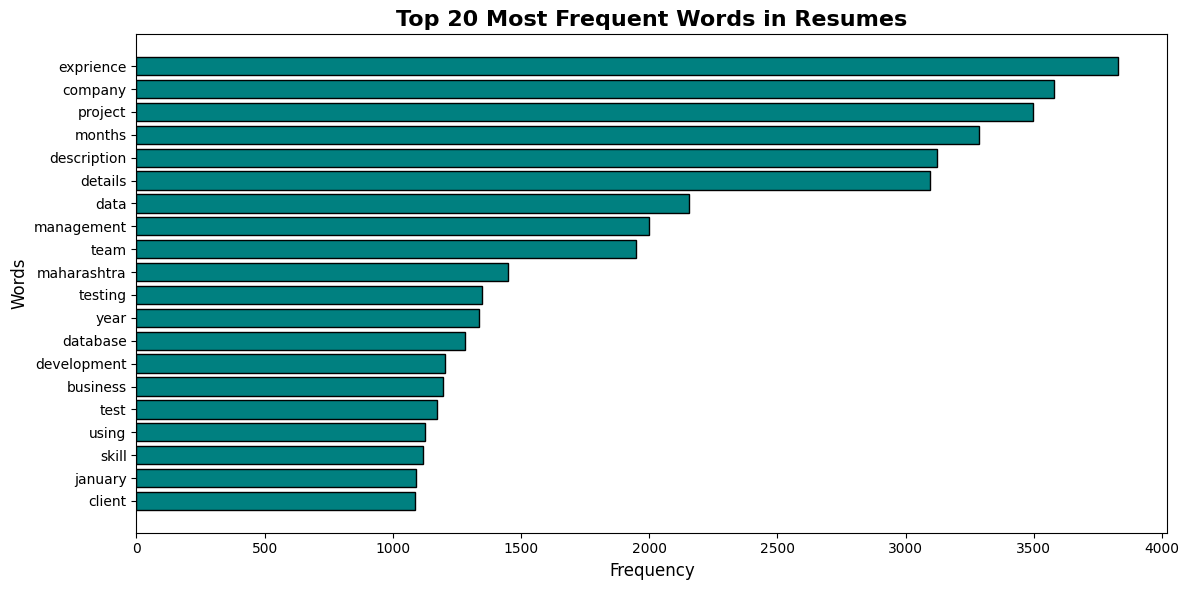

In [24]:
words, counts = zip(*top_words)
plt.figure(figsize=(12, 6))
plt.barh(words, counts, color='teal', edgecolor='black')
plt.title('Top 20 Most Frequent Words in Resumes', fontsize=16, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_words.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n" + "="*50)
print("MODEL TRAINING")
print("="*50)

vectorizer = TfidfVectorizer(max_features=1500, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_resume'])
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

model = OneVsRestClassifier(KNeighborsClassifier())
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(df['Category'].unique()),
            yticklabels=sorted(df['Category'].unique()))
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

import pickle
with open('resume_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved successfully!")


MODEL TRAINING

Training set size: 769
Test set size: 193

Model Accuracy: 0.9793 (97.93%)

CLASSIFICATION REPORT
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         3
                     Arts       1.00      1.00      1.00         6
       Automation Testing       1.00      1.00      1.00         5
               Blockchain       1.00      1.00      1.00         7
         Business Analyst       1.00      1.00      1.00         4
           Civil Engineer       1.00      1.00      1.00         9
             Data Science       0.75      0.60      0.67         5
                 Database       1.00      0.88      0.93         8
          DevOps Engineer       1.00      0.93      0.96        14
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         7
   Electrical Engineering       1.00      1.00      1.00         6
             